## Open In Colab

[![Run in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/achyutmorang/waymax-simulation-experiments/blob/main/experiments/risk-uq-suite/notebooks/00_probe/miscalibration_interpretation_colab.ipynb)


# Risk/UQ Paper Track: Miscalibration Interpretation

## Objective
Load already-saved `miscalibration_probe` artifacts from persistent storage and convert them into a formal verdict on your hypothesis.

This notebook answers, from evidence:
1. Are planner-side risk proxies miscalibrated?
2. Do budgeted decisions become over-confident (`false-safe`) or under-confident (`safe-rejected`)?
3. Does calibration reduce those decision errors?


## Hypotheses Being Adjudicated

- `H1`: Raw planner proxy risk is miscalibrated (nominal ECE is non-trivial and/or NLL is high).
- `H2`: Under a safety budget `tau`, raw probabilities lead to unsafe acceptances (false-safe > 0).
- `H3`: Calibrated probabilities improve reliability metrics and decision-level error rates relative to raw.
- `H4`: Miscalibration/decision error worsens under non-nominal shift suites.

Output includes a claim-by-claim verdict table with `supported`, `not_supported`, or `inconclusive`.


## Step 1 - Deterministic Bootstrap Constants


In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = 'https://github.com/achyutmorang/waymax-simulation-experiments.git'
REPO_DIR = '/content/waymax-simulation-experiments'
REPO_BRANCH = 'main'
EXPERIMENT_SLUG = 'risk-uq-suite'
EXPERIMENT_CONFIG_PATH = f'{REPO_DIR}/configs/experiments/{EXPERIMENT_SLUG}.json'
REQUIRED_DRIVE_FOLDER = '/content/drive/MyDrive/waymax_experiments'

runtime_cfg_overrides = {
    'verify_drive_access_every_run': False,
    'force_reinstall': False,
    'auto_restart_after_setup': True,
    'strict_lockfile_check': True,
    'setup_cache_enabled': True,
    'revalidate_core_imports_on_cache_hit': True,
    'setup_cache_path': '/content/.closedloop_setup_cache.json',
    'force_module_hot_reload': True,
}

content_root = Path('/content')
content_root.mkdir(parents=True, exist_ok=True)
try:
    _ = os.getcwd()
except FileNotFoundError:
    os.chdir(str(content_root))


## Step 2 - Storage Setup


In [2]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as exc:
    print('[storage] google.colab drive mount unavailable:', exc)

drive_root = Path('/content/drive/MyDrive')
if not drive_root.exists():
    raise RuntimeError('Drive root not found at /content/drive/MyDrive. Ensure Google Drive is mounted.')

required_root = Path(REQUIRED_DRIVE_FOLDER)
required_root.mkdir(parents=True, exist_ok=True)
probe = required_root / '.risk_uq_storage_probe'
probe.write_text('ok')
probe.unlink(missing_ok=True)
print('[storage] ready:', required_root)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[storage] ready: /content/drive/MyDrive/waymax_experiments


## Step 3 - Repo Sync + Runtime Bootstrap


In [3]:
if not Path(REPO_DIR).exists():
    subprocess.run(['git', 'clone', '--depth', '1', '-b', REPO_BRANCH, REPO_URL, REPO_DIR], check=True)

for p in (REPO_DIR, f'{REPO_DIR}/src'):
    if p not in sys.path:
        sys.path.insert(0, p)

from src.platform import ColabRuntimeConfig, bootstrap_colab_runtime_with_config

runtime_cfg = ColabRuntimeConfig(
    repo_url=REPO_URL,
    repo_dir=REPO_DIR,
    repo_branch=REPO_BRANCH,
    required_drive_folder=REQUIRED_DRIVE_FOLDER,
    **runtime_cfg_overrides,
)
bootstrap = bootstrap_colab_runtime_with_config(runtime_cfg)

globals()['_RISK_UQ_REPO_REV'] = str(bootstrap.repo_sync.repo_rev)
setup_result = bootstrap.setup.result

print('Working directory:', os.getcwd())
print('Repo commit:', bootstrap.repo_sync.repo_rev)
print('Drive mounted:', bootstrap.drive_status.mounted)
print('[setup] result:', setup_result)
if bool(setup_result.get('restart_required', False)) and (not bool(runtime_cfg.auto_restart_after_setup)):
    print('[setup] restart_required=True; restart runtime before continuing.')


[repo] existing checkout: /content/waymax-simulation-experiments
[drive] /content/drive already mounted
[drive] Verified read/write access: /content/drive/MyDrive/waymax_experiments
[setup] Starting deterministic environment bootstrap
[setup] Lockfile version check: no exact-pin mismatches detected.
[setup] $ /usr/bin/python3 -c import jax, waymax, numpy as np, pandas as pd, scipy, sklearn; from numpy._core.umath import _center, _expandtabs; print('ok', np.__version__, pd.__version__, scipy.__version__, sklearn.__version__, jax.__version__)
[setup] Core runtime already healthy; skipping dependency install (ok 2.2.6 2.2.3 1.14.1 1.6.1 0.7.2).
[setup] LatentDriver repo already exists: /content/LatentDriver
[patch] gpt2_model block already patched or changed
[patch] sort_vert fallback patch applied
[ckpt] already present: /content/checkpoints/lantentdriver_t2_J3.ckpt
[setup] $ /usr/bin/python3 -c import numpy as np; from numpy._core.umath import _center, _expandtabs; print(np.__version__,

## Step 4 - Configuration + Run Context


In [4]:
from src.workflows import (
    initialize_risk_uq_run_context,
    load_experiment_config,
    report_risk_uq_run_context,
)

EXPERIMENT_CFG = load_experiment_config(
    slug=EXPERIMENT_SLUG,
    repo_root=REPO_DIR,
    default_on_missing=False,
)
run_cfg = dict(EXPERIMENT_CFG.get('run', {}))

RUN_NAME = str(run_cfg.get('run_name', '')).strip()
RUN_PREFIX = str(run_cfg.get('run_prefix', 'risk_uq')).strip() or 'risk_uq'
PERSIST_ROOT = str(run_cfg.get('persist_root', '/content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1')).strip()
N_SHARDS = int(max(1, int(run_cfg.get('n_shards', 1))))
SHARD_ID = run_cfg.get('shard_id', 'auto')
RESUME_FROM_EXISTING = bool(run_cfg.get('resume_from_existing', True))
RUN_ENABLED = bool(run_cfg.get('run_enabled', True))

RUN_TAG_PREFIX = str(run_cfg.get('run_tag_prefix', RUN_PREFIX)).strip() or RUN_PREFIX
RUN_MODE_CFG = str(run_cfg.get('run_mode', 'auto')).strip().lower() or 'auto'
RUN_MODE = RUN_MODE_CFG if RESUME_FROM_EXISTING else 'fresh'
RUN_TAG = RUN_NAME

run_ctx = initialize_risk_uq_run_context(
    run_tag=RUN_TAG,
    run_tag_prefix=RUN_TAG_PREFIX,
    persist_root=PERSIST_ROOT,
    n_shards=N_SHARDS,
    shard_id=SHARD_ID,
    resume_mode=RUN_MODE,
    resume_from_existing=bool(RESUME_FROM_EXISTING),
    planner_backend='latentdriver',
)

cfg = run_ctx.cfg
search_cfg = {}
RUN_TAG = str(run_ctx.run_tag)
RUN_NAME = str(RUN_NAME or RUN_TAG)
SHARD_ID = int(run_ctx.shard_id)

# Interpretation knobs
ANALYSIS_RUN_PREFIX_OVERRIDE = ''  # optional absolute run_prefix from a previous probe run
FOCUS_LABEL = 'failure_proxy_h15'
RISK_BUDGET_TAU = 0.20
MAX_DISCOVERED_RUNS = 50

# Tau sweep knobs for decision diagnostics
TAU_SWEEP_MIN = 0.05
TAU_SWEEP_MAX = 0.80
TAU_SWEEP_POINTS = 16
TAU_SWEEP_BOOTSTRAP_SAMPLES = 200
TAU_SWEEP_BOOTSTRAP_SEED = 17

print('EXPERIMENT_CONFIG_PATH =', EXPERIMENT_CONFIG_PATH)
print('candidate run_prefix from config =', cfg.run_prefix)
print('RUN_PREFIX/RUN_NAME (contract dir) =', RUN_PREFIX, RUN_NAME)
print('RUN_ENABLED =', RUN_ENABLED, ' RESUME_FROM_EXISTING =', RESUME_FROM_EXISTING)
report_risk_uq_run_context(run_ctx, display_fn=display)



[config auto-fix] latentdriver_context_len increased from 2 to 10 to match history_steps.
[ckpt] using configured checkpoint: /content/checkpoints/lantentdriver_t2_J3.ckpt
[ckpt] final cfg.latentdriver_ckpt_path = /content/checkpoints/lantentdriver_t2_J3.ckpt
EXPERIMENT_CONFIG_PATH = /content/waymax-simulation-experiments/configs/experiments/risk-uq-suite.json
candidate run_prefix from config = /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_200935
RUN_PREFIX/RUN_NAME (contract dir) = risk_uq risk_uq_20260228_200935
RUN_ENABLED = True  RESUME_FROM_EXISTING = True


,field,value
0,run_tag,risk_uq_20260228_200935
1,run_prefix,/content/drive/MyDrive/waymax_experiments/risk...
2,run_mode,auto
3,planner_backend,latentdriver
4,persist_root,/content/drive/MyDrive/waymax_experiments/risk...
5,n_shards,1
6,shard_id,0
7,resume_from_existing,1
8,latentdriver_ckpt_path,/content/checkpoints/lantentdriver_t2_J3.ckpt


,path,name,size_mb,mtime_utc,root,root_rank,name_score,score
0,/content/checkpoints/lantentdriver_t2_J3.ckpt,lantentdriver_t2_J3.ckpt,116.742193,2026-02-28T19:56:48Z,/content/checkpoints,0,100,100100.011674


## Step 5 - Locate Available Probe Artifacts


In [5]:
from src.workflows import (
    discover_probe_run_prefixes,
    has_existing_miscalibration_probe_artifacts,
)

analysis_run_prefix = str(ANALYSIS_RUN_PREFIX_OVERRIDE).strip() or str(cfg.run_prefix)
discovered_runs_df = discover_probe_run_prefixes(PERSIST_ROOT, limit=MAX_DISCOVERED_RUNS)

if not discovered_runs_df.empty:
    print('[artifacts] discovered probe runs (most recent first):')
    display(discovered_runs_df.head(20))
else:
    print('[artifacts] no probe runs discovered under PERSIST_ROOT:', PERSIST_ROOT)

ALLOW_PREVIOUS_RUN_FALLBACK = bool(run_cfg.get('allow_previous_run_fallback', True))
if (not has_existing_miscalibration_probe_artifacts(analysis_run_prefix)) and (not discovered_runs_df.empty):
    if ALLOW_PREVIOUS_RUN_FALLBACK:
        analysis_run_prefix = str(discovered_runs_df.iloc[0]['run_prefix'])
        print('[artifacts] current run missing probe artifacts; falling back to latest discovered run:', analysis_run_prefix)
    else:
        print('[artifacts] current run missing probe artifacts; fallback disabled.')

print('analysis_run_prefix =', analysis_run_prefix)
print('artifacts_present =', has_existing_miscalibration_probe_artifacts(analysis_run_prefix))

if bool(RUN_ENABLED) and (not has_existing_miscalibration_probe_artifacts(analysis_run_prefix)):
    raise FileNotFoundError(
        'No completed miscalibration probe artifacts were found for analysis_run_prefix. '
        'Run miscalibration_probe_colab.ipynb for this run, or set allow_previous_run_fallback=true.'
    )


[artifacts] discovered probe runs (most recent first):


,run_prefix,summary_path,mtime_utc
0,/content/drive/MyDrive/waymax_experiments/risk...,/content/drive/MyDrive/waymax_experiments/risk...,2026-02-28 17:48:42+00:00


analysis_run_prefix = /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758
artifacts_present = True


## Step 6 - Load Artifacts and Adjudicate Hypotheses


In [6]:
import numpy as np
import pandas as pd
from src.workflows import (
    compute_threshold_sweep_diagnostics,
    load_and_analyze_miscalibration_probe,
    resolve_threshold_sweep_variants,
)

interpret_bundle = None
tau_sweep_df = pd.DataFrame()
tau_budget_summary_df = pd.DataFrame()
selected_variant_map = {}

if not bool(RUN_ENABLED):
    print('[main] skipped: RUN_ENABLED=False')
else:
    interpret_bundle = load_and_analyze_miscalibration_probe(
        run_prefix=analysis_run_prefix,
        focus_label=FOCUS_LABEL,
        threshold=RISK_BUDGET_TAU,
    )
    print(interpret_bundle.narrative)
    display(interpret_bundle.verdict_df)

    key_cols = [
        'scope', 'variant_group', 'ece', 'nll', 'brier',
        'empirical_failure_given_accepted', 'false_safe_rate',
        'safe_rejected_rate', 'budget_violated_rate',
    ]
    key_cols = [c for c in key_cols if c in interpret_bundle.metric_summary_df.columns]
    display(interpret_bundle.metric_summary_df.loc[:, key_cols])

    final_claim = interpret_bundle.verdict_df[
        interpret_bundle.verdict_df['claim'].astype(str).eq('Problem framing validated (miscalibration + decision impact)')
    ]
    if not final_claim.empty:
        print('[hypothesis verdict]', str(final_claim.iloc[0]['status']).upper())
    else:
        print('[hypothesis verdict] INCONCLUSIVE (missing final claim row)')

    pred_df = interpret_bundle.source_bundle.predictions_df.copy()
    variant_map_all = resolve_threshold_sweep_variants(pred_df, focus_label=FOCUS_LABEL)
    per_shift_focus = interpret_bundle.per_shift_focus_df.copy()

    def _pick_variant(group: str, preferred: str):
        if preferred in variant_map_all:
            return preferred
        if (not per_shift_focus.empty) and {'variant', 'variant_group'}.issubset(per_shift_focus.columns):
            sub = per_shift_focus[per_shift_focus['variant_group'].astype(str).eq(group)].copy()
            if not sub.empty:
                if 'n_rows' in sub.columns:
                    sub = sub.sort_values('n_rows', ascending=False)
                for v in sub['variant'].astype(str).tolist():
                    if v in variant_map_all:
                        return v
        for v in variant_map_all.keys():
            v_low = str(v).lower()
            v_group = 'raw' if ('raw' in v_low) else ('cal' if ('platt' in v_low or 'cal' in v_low) else 'other')
            if v_group == group:
                return v
        return None

    raw_variant = _pick_variant('raw', 'planner_combo_raw')
    cal_variant = _pick_variant('cal', 'planner_combo_platt')

    if raw_variant is not None:
        selected_variant_map[str(raw_variant)] = variant_map_all[str(raw_variant)]
    if cal_variant is not None:
        selected_variant_map[str(cal_variant)] = variant_map_all[str(cal_variant)]
    if len(selected_variant_map) == 0:
        selected_variant_map = dict(variant_map_all)

    tau_values = np.linspace(
        float(TAU_SWEEP_MIN),
        float(TAU_SWEEP_MAX),
        int(max(2, int(TAU_SWEEP_POINTS))),
    )

    tau_sweep_df = compute_threshold_sweep_diagnostics(
        pred_df,
        focus_label=FOCUS_LABEL,
        tau_values=tau_values,
        variants=selected_variant_map,
        bootstrap_samples=int(max(0, int(TAU_SWEEP_BOOTSTRAP_SAMPLES))),
        bootstrap_seed=int(TAU_SWEEP_BOOTSTRAP_SEED),
    )

    if tau_sweep_df.empty:
        print('[tau sweep] no rows produced')
    else:
        tau_target = float(RISK_BUDGET_TAU)
        tau_budget_view = tau_sweep_df.copy()
        tau_budget_view['tau_distance'] = np.abs(pd.to_numeric(tau_budget_view['tau'], errors='coerce') - tau_target)
        tau_budget_summary_df = (
            tau_budget_view.sort_values('tau_distance')
            .groupby(['shift_suite', 'variant_group'], as_index=False)
            .first()
        )
        budget_cols = [
            'shift_suite',
            'variant_group',
            'tau',
            'accept_count',
            'accept_rate',
            'false_safe_cond',
            'safe_reject_cond',
            'feasible_set_rate',
            'fallback_rate',
        ]
        budget_cols = [c for c in budget_cols if c in tau_budget_summary_df.columns]
        print('[tau sweep] selected variants =', selected_variant_map)
        display(tau_budget_summary_df.loc[:, budget_cols])



Overall verdict for focus label failure_proxy_h15: supported. Use the claim-level verdict table to see exactly which links in the chain (miscalibration -> budget decision error) are supported.


,claim,status,evidence
0,Planner-side proxy miscalibration exists (nomi...,supported,raw_nominal_ece=0.9056
1,Calibration improves reliability (nominal),supported,ece raw=0.9056 vs cal=0.1422; nll raw=5.9186 v...
2,Budgeted decisions show over-confidence at tau...,inconclusive,empirical_failure_given_accepted unavailable
3,Budgeted decisions show under-confidence (safe...,supported,"safe_rejected_rate raw=1.0000, cal=0.2667"
4,Miscalibration worsens under shift,not_supported,"raw_ece nominal=0.9056, shift_mean=0.6806"
5,Problem framing validated (miscalibration + de...,supported,"miscalibration=True, over_confident_budget=Non..."


,scope,variant_group,ece,nll,brier,empirical_failure_given_accepted,false_safe_rate,safe_rejected_rate,budget_violated_rate
0,nominal,raw,0.905555,5.918568,0.824907,NaN,0.0000,1.000000,0.000000
1,nominal,cal,0.142216,0.156315,0.024583,0.000000,0.0000,0.266667,0.000000
2,shift_only,raw,0.680555,4.609868,0.642407,NaN,0.0000,0.775000,0.000000
3,shift_only,cal,0.092403,0.522263,0.171254,0.151923,0.1250,0.133333,0.333333
4,all,raw,0.793055,5.264218,0.733657,NaN,0.0000,0.887500,0.000000
5,all,cal,0.117310,0.339289,0.097919,0.075962,0.0625,0.200000,0.166667


[hypothesis verdict] SUPPORTED
[tau sweep] selected variants = {'planner_combo_raw': 'planner_risk_combo_proxy', 'planner_combo_platt': 'planner_risk_combo_platt'}


,shift_suite,variant_group,tau,accept_count,accept_rate,false_safe_cond,safe_reject_cond,feasible_set_rate,fallback_rate
0,high_interaction_holdout,cal,0.2,208.0,0.65,0.115385,0.571429,0.65,0.35
1,high_interaction_holdout,raw,0.2,0.0,0.00,NaN,0.775000,0.00,1.00
2,nominal_clean,cal,0.2,120.0,0.60,0.000000,1.000000,0.60,0.40
3,nominal_clean,raw,0.2,0.0,0.00,NaN,1.000000,0.00,1.00


## Step 7 - Plots (Reliability, Shift Error, Budget Diagnostics, Tau Sweep)


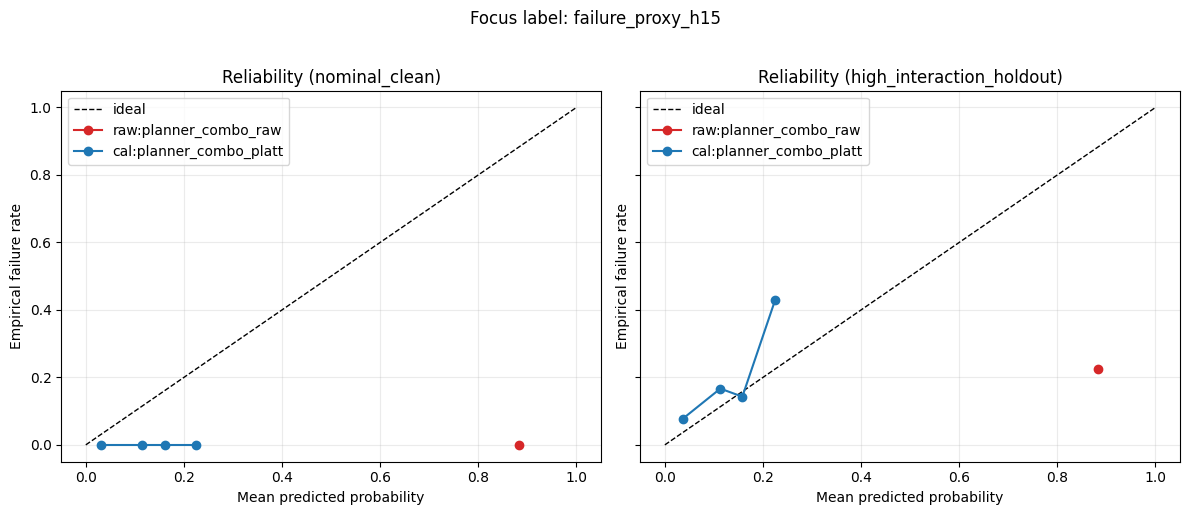

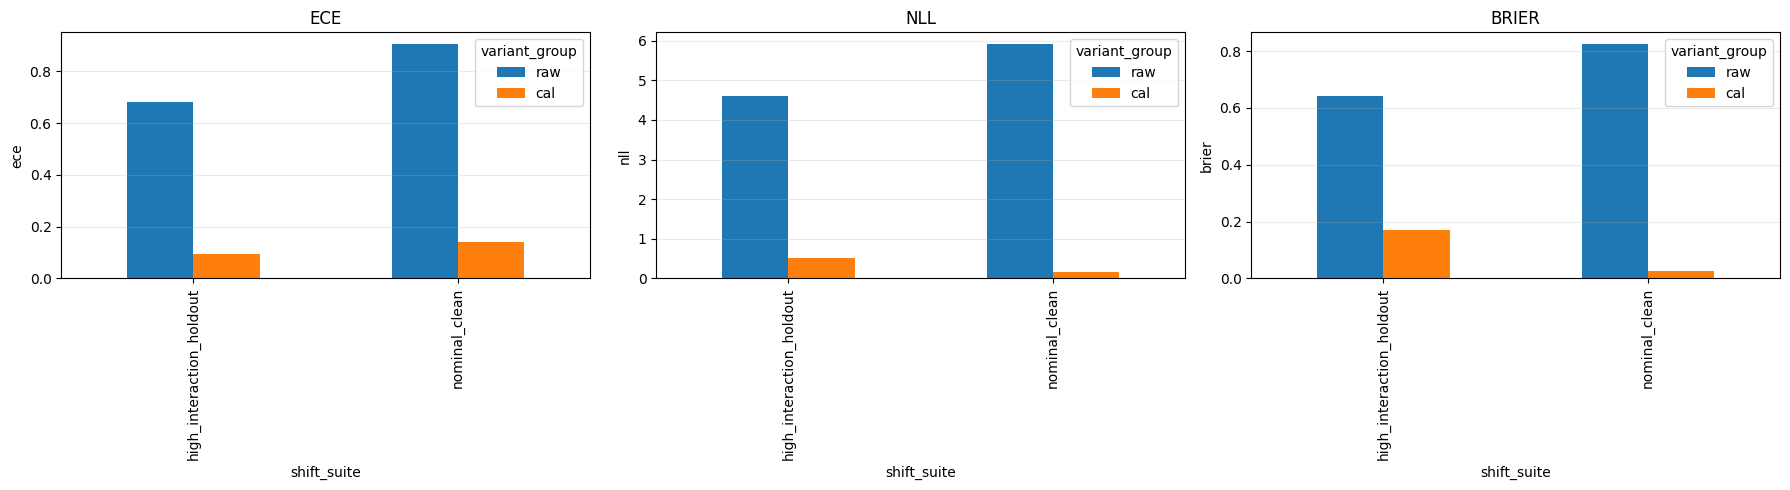

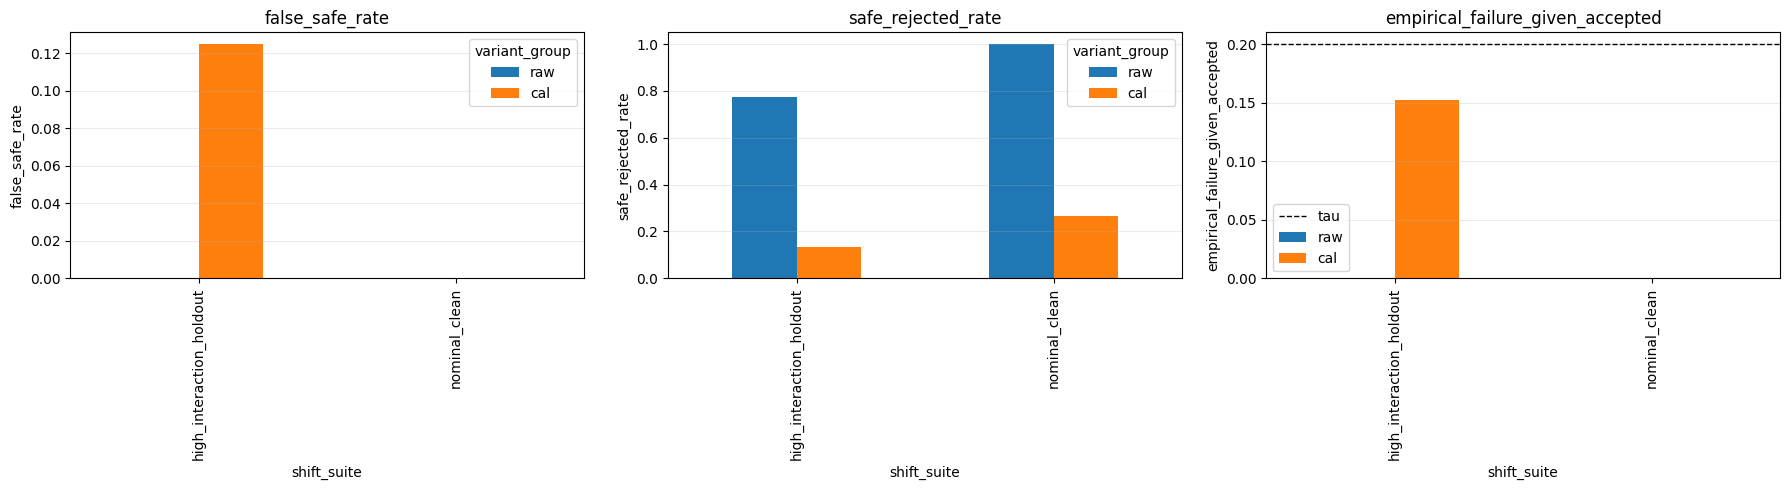

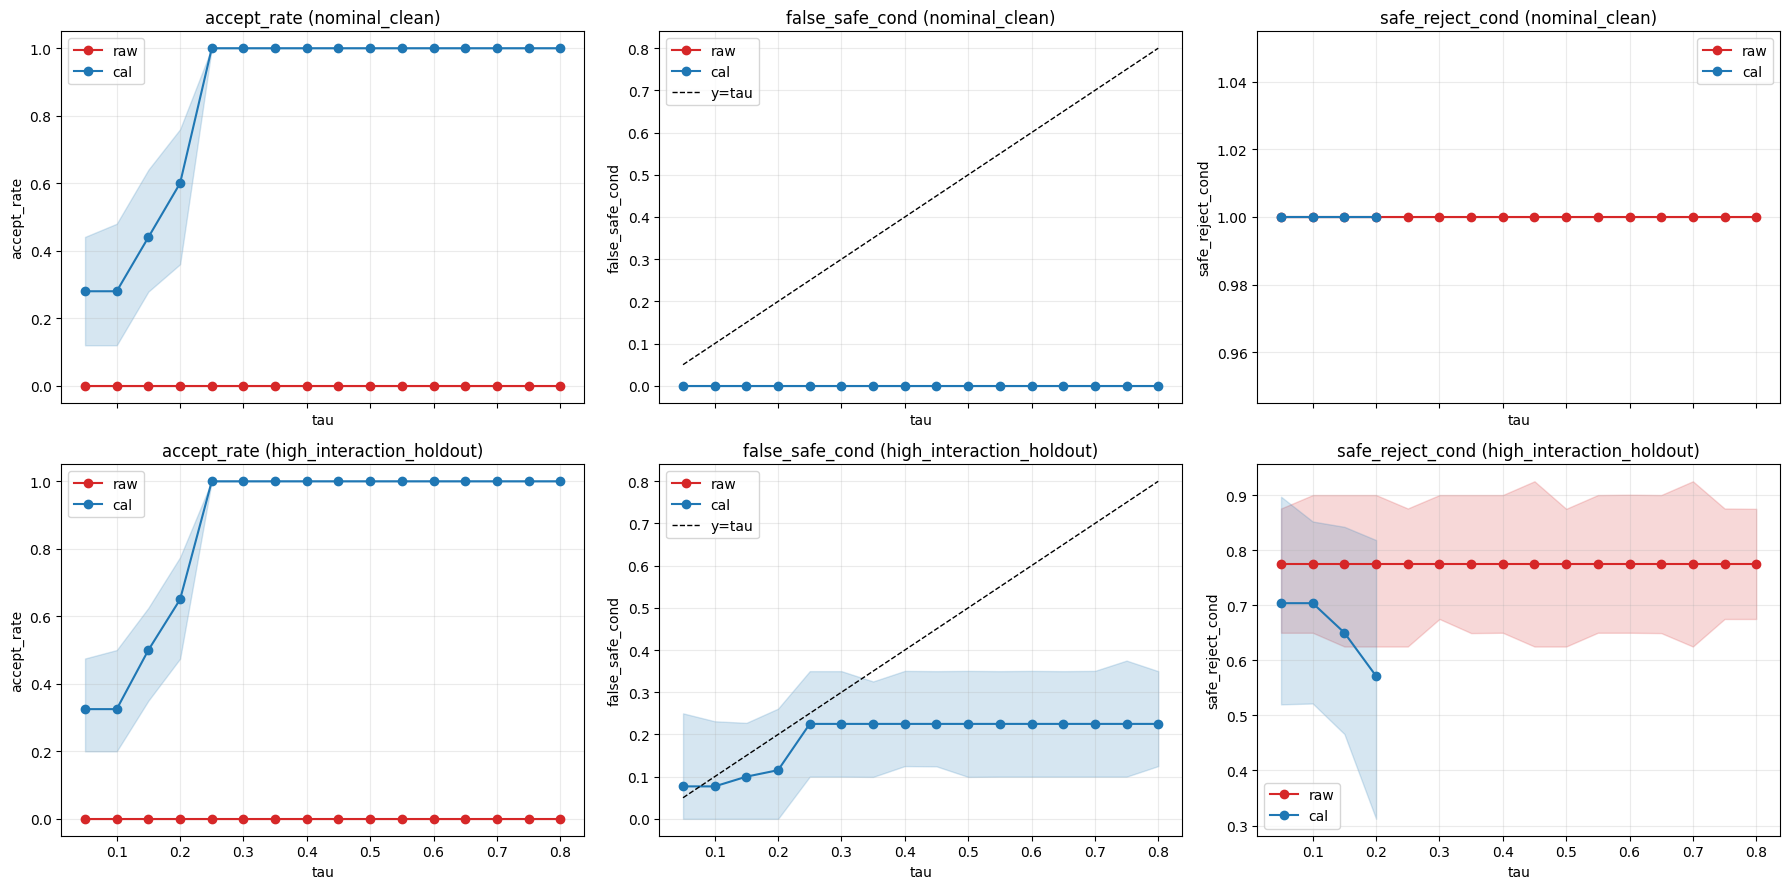

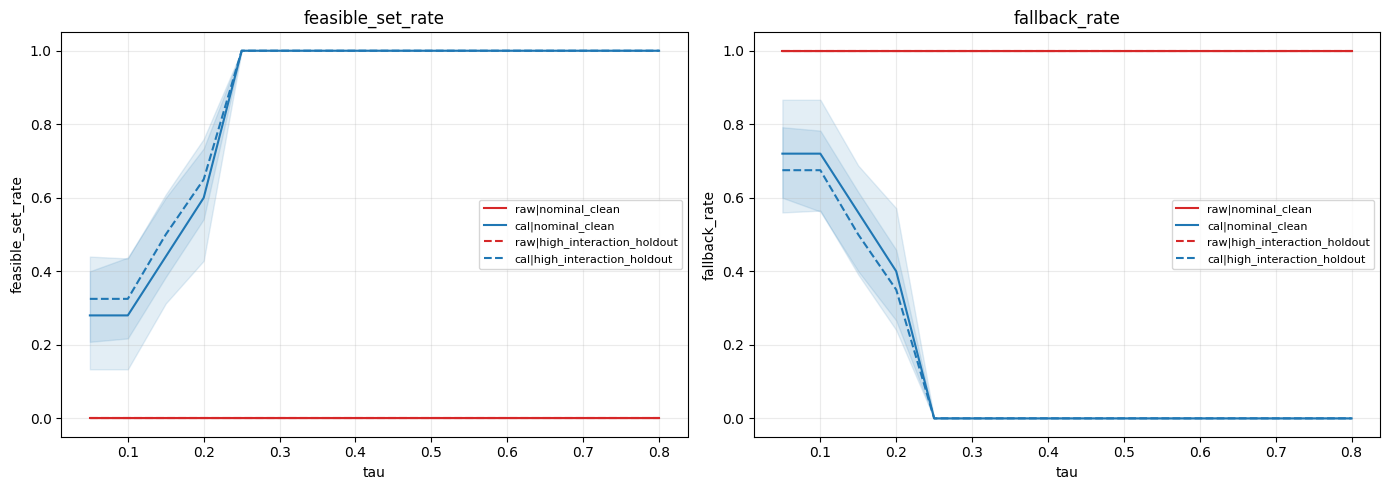

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

figure_paths = {}

if interpret_bundle is None:
    print('[plots] skipped: no interpretation bundle')
else:
    # Plot A: reliability diagram for one nominal and one shifted suite.
    rel = interpret_bundle.reliability_focus_df.copy()
    if not rel.empty and {'mean_prob', 'event_rate', 'shift_suite', 'variant', 'variant_group'}.issubset(rel.columns):
        def _pick_rel_variant(rel_df: pd.DataFrame, group: str, preferred: str):
            sub = rel_df[rel_df['variant_group'].astype(str).eq(group)]
            if sub.empty:
                return None
            if sub['variant'].astype(str).eq(preferred).any():
                return preferred
            return str(sub['variant'].astype(str).iloc[0])

        raw_variant = _pick_rel_variant(rel, 'raw', 'planner_combo_raw')
        cal_variant = _pick_rel_variant(rel, 'cal', 'planner_combo_platt')

        shifts = ['nominal_clean']
        non_nom = sorted([s for s in rel['shift_suite'].astype(str).unique().tolist() if s != 'nominal_clean'])
        if len(non_nom) > 0:
            shifts.append(non_nom[0])

        fig, axes = plt.subplots(1, len(shifts), figsize=(6 * len(shifts), 5), sharex=True, sharey=True)
        if len(shifts) == 1:
            axes = [axes]

        for ax, shift_suite in zip(axes, shifts):
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='ideal')
            for group, variant, color in [
                ('raw', raw_variant, 'tab:red'),
                ('cal', cal_variant, 'tab:blue'),
            ]:
                if variant is None:
                    continue
                sub = rel[
                    rel['shift_suite'].astype(str).eq(shift_suite)
                    & rel['variant'].astype(str).eq(variant)
                ].sort_values('mean_prob')
                if sub.empty:
                    continue
                ax.plot(
                    sub['mean_prob'].to_numpy(dtype=float),
                    sub['event_rate'].to_numpy(dtype=float),
                    marker='o',
                    linewidth=1.5,
                    label=f'{group}:{variant}',
                    color=color,
                )
            ax.set_title(f'Reliability ({shift_suite})')
            ax.set_xlabel('Mean predicted probability')
            ax.set_ylabel('Empirical failure rate')
            ax.grid(alpha=0.25)
            ax.legend(loc='best')

        fig.suptitle(f'Focus label: {FOCUS_LABEL}', y=1.02)
        fig.tight_layout()
        rel_plot_path = f'{analysis_run_prefix}_miscalibration_interpretation_reliability.png'
        fig.savefig(rel_plot_path, dpi=160, bbox_inches='tight')
        figure_paths['reliability_plot'] = rel_plot_path
        plt.show()
    else:
        print('[plots] reliability plot skipped: required columns missing')

    # Plot B: ECE/NLL/Brier by shift for raw vs cal groups.
    per = interpret_bundle.per_shift_focus_df.copy()
    if not per.empty and {'shift_suite', 'variant_group', 'ece', 'nll', 'brier'}.issubset(per.columns):
        agg = (
            per.groupby(['shift_suite', 'variant_group'], as_index=False)
            .agg(ece=('ece', 'mean'), nll=('nll', 'mean'), brier=('brier', 'mean'))
        )
        metric_names = ['ece', 'nll', 'brier']
        fig, axes = plt.subplots(1, len(metric_names), figsize=(6 * len(metric_names), 5))
        for ax, metric in zip(axes, metric_names):
            pivot = agg.pivot(index='shift_suite', columns='variant_group', values=metric)
            preferred_cols = [c for c in ['raw', 'cal', 'other'] if c in pivot.columns]
            pivot = pivot.loc[:, preferred_cols]
            pivot.plot(kind='bar', ax=ax)
            ax.set_title(metric.upper())
            ax.set_xlabel('shift_suite')
            ax.set_ylabel(metric)
            ax.grid(axis='y', alpha=0.25)
        fig.tight_layout()
        shift_plot_path = f'{analysis_run_prefix}_miscalibration_interpretation_shift_metrics.png'
        fig.savefig(shift_plot_path, dpi=160, bbox_inches='tight')
        figure_paths['shift_metrics_plot'] = shift_plot_path
        plt.show()
    else:
        print('[plots] shift metric plot skipped: required columns missing')

    # Plot C: single-tau diagnostics under risk budget tau.
    thr = interpret_bundle.threshold_focus_df.copy()
    required_thr = {'shift_suite', 'variant_group', 'false_safe_rate', 'safe_rejected_rate'}
    if not thr.empty and required_thr.issubset(thr.columns):
        agg_thr = (
            thr.groupby(['shift_suite', 'variant_group'], as_index=False)
            .agg(
                false_safe_rate=('false_safe_rate', 'mean'),
                safe_rejected_rate=('safe_rejected_rate', 'mean'),
                empirical_failure_given_accepted=('empirical_failure_given_accepted', 'mean'),
                accepted_rate=('accepted_rate', 'mean'),
            )
        )

        metrics = ['false_safe_rate', 'safe_rejected_rate', 'empirical_failure_given_accepted']
        fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
        for ax, metric in zip(axes, metrics):
            pivot = agg_thr.pivot(index='shift_suite', columns='variant_group', values=metric)
            preferred_cols = [c for c in ['raw', 'cal', 'other'] if c in pivot.columns]
            pivot = pivot.loc[:, preferred_cols]
            pivot.plot(kind='bar', ax=ax)
            ax.set_title(metric)
            ax.set_xlabel('shift_suite')
            ax.set_ylabel(metric)
            if metric == 'empirical_failure_given_accepted':
                ax.axhline(float(RISK_BUDGET_TAU), color='k', linestyle='--', linewidth=1, label='tau')
                ax.legend(loc='best')
            ax.grid(axis='y', alpha=0.25)

        fig.tight_layout()
        thr_plot_path = f'{analysis_run_prefix}_miscalibration_interpretation_threshold_diagnostics.png'
        fig.savefig(thr_plot_path, dpi=160, bbox_inches='tight')
        figure_paths['threshold_plot'] = thr_plot_path
        plt.show()
    else:
        print('[plots] threshold diagnostic plot skipped: required columns missing')

    # Plot D: tau sweep decision metrics with optional bootstrap CIs.
    tau_plot_df = tau_sweep_df.copy()
    required_tau = {
        'tau', 'shift_suite', 'variant_group',
        'accept_rate', 'false_safe_cond', 'safe_reject_cond',
    }
    if (not tau_plot_df.empty) and required_tau.issubset(tau_plot_df.columns):
        selected_shifts = ['nominal_clean']
        non_nom = sorted([s for s in tau_plot_df['shift_suite'].astype(str).unique().tolist() if s != 'nominal_clean'])
        if len(non_nom) > 0:
            selected_shifts.append(non_nom[0])

        metrics = ['accept_rate', 'false_safe_cond', 'safe_reject_cond']
        fig, axes = plt.subplots(len(selected_shifts), len(metrics), figsize=(6 * len(metrics), 4.5 * len(selected_shifts)), sharex=True)
        if len(selected_shifts) == 1:
            axes = np.asarray([axes])

        for row_id, shift_suite in enumerate(selected_shifts):
            sub_shift = tau_plot_df[tau_plot_df['shift_suite'].astype(str).eq(str(shift_suite))]
            for col_id, metric in enumerate(metrics):
                ax = axes[row_id, col_id]
                for group, color in [('raw', 'tab:red'), ('cal', 'tab:blue')]:
                    sub = sub_shift[sub_shift['variant_group'].astype(str).eq(group)].copy()
                    if sub.empty:
                        continue
                    line_df = sub.groupby('tau', as_index=False)[metric].mean().sort_values('tau')
                    ax.plot(
                        line_df['tau'].to_numpy(dtype=float),
                        line_df[metric].to_numpy(dtype=float),
                        marker='o',
                        linewidth=1.5,
                        color=color,
                        label=group,
                    )

                    low_col = f'{metric}_ci_low'
                    high_col = f'{metric}_ci_high'
                    if low_col in sub.columns and high_col in sub.columns:
                        ci_df = sub.groupby('tau', as_index=False).agg(
                            ci_low=(low_col, 'mean'),
                            ci_high=(high_col, 'mean'),
                        ).sort_values('tau')
                        merged = line_df.merge(ci_df, on='tau', how='left')
                        valid = np.isfinite(merged['ci_low'].to_numpy(dtype=float)) & np.isfinite(merged['ci_high'].to_numpy(dtype=float))
                        if bool(np.any(valid)):
                            ax.fill_between(
                                merged.loc[valid, 'tau'].to_numpy(dtype=float),
                                merged.loc[valid, 'ci_low'].to_numpy(dtype=float),
                                merged.loc[valid, 'ci_high'].to_numpy(dtype=float),
                                color=color,
                                alpha=0.18,
                            )

                if metric == 'false_safe_cond':
                    tau_line = np.linspace(float(sub_shift['tau'].min()), float(sub_shift['tau'].max()), 64)
                    ax.plot(tau_line, tau_line, 'k--', linewidth=1, label='y=tau')

                ax.set_title(f'{metric} ({shift_suite})')
                ax.set_xlabel('tau')
                ax.set_ylabel(metric)
                ax.grid(alpha=0.25)
                ax.legend(loc='best')

        fig.tight_layout()
        tau_plot_path = f'{analysis_run_prefix}_miscalibration_interpretation_tau_sweep_decision_metrics.png'
        fig.savefig(tau_plot_path, dpi=160, bbox_inches='tight')
        figure_paths['tau_sweep_decision_plot'] = tau_plot_path
        plt.show()
    else:
        print('[plots] tau-sweep decision plot skipped: required columns missing')

    # Plot E: feasible-set and fallback vs tau.
    required_feas = {'tau', 'shift_suite', 'variant_group', 'feasible_set_rate', 'fallback_rate'}
    if (not tau_plot_df.empty) and required_feas.issubset(tau_plot_df.columns):
        selected_shifts = ['nominal_clean']
        non_nom = sorted([s for s in tau_plot_df['shift_suite'].astype(str).unique().tolist() if s != 'nominal_clean'])
        if len(non_nom) > 0:
            selected_shifts.append(non_nom[0])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
        for ax, metric in zip(axes, ['feasible_set_rate', 'fallback_rate']):
            for shift_suite in selected_shifts:
                for group, color in [('raw', 'tab:red'), ('cal', 'tab:blue')]:
                    sub = tau_plot_df[
                        tau_plot_df['shift_suite'].astype(str).eq(str(shift_suite))
                        & tau_plot_df['variant_group'].astype(str).eq(group)
                    ].copy()
                    if sub.empty:
                        continue
                    line_df = sub.groupby('tau', as_index=False)[metric].mean().sort_values('tau')
                    linestyle = '-' if str(shift_suite) == 'nominal_clean' else '--'
                    label = f'{group}|{shift_suite}'
                    ax.plot(
                        line_df['tau'].to_numpy(dtype=float),
                        line_df[metric].to_numpy(dtype=float),
                        linewidth=1.5,
                        linestyle=linestyle,
                        color=color,
                        label=label,
                    )

                    low_col = f'{metric}_ci_low'
                    high_col = f'{metric}_ci_high'
                    if low_col in sub.columns and high_col in sub.columns:
                        ci_df = sub.groupby('tau', as_index=False).agg(
                            ci_low=(low_col, 'mean'),
                            ci_high=(high_col, 'mean'),
                        ).sort_values('tau')
                        merged = line_df.merge(ci_df, on='tau', how='left')
                        valid = np.isfinite(merged['ci_low'].to_numpy(dtype=float)) & np.isfinite(merged['ci_high'].to_numpy(dtype=float))
                        if bool(np.any(valid)):
                            ax.fill_between(
                                merged.loc[valid, 'tau'].to_numpy(dtype=float),
                                merged.loc[valid, 'ci_low'].to_numpy(dtype=float),
                                merged.loc[valid, 'ci_high'].to_numpy(dtype=float),
                                color=color,
                                alpha=0.12,
                            )

            ax.set_title(metric)
            ax.set_xlabel('tau')
            ax.set_ylabel(metric)
            ax.grid(alpha=0.25)
            ax.legend(loc='best', fontsize=8)

        fig.tight_layout()
        feas_plot_path = f'{analysis_run_prefix}_miscalibration_interpretation_tau_sweep_feasibility.png'
        fig.savefig(feas_plot_path, dpi=160, bbox_inches='tight')
        figure_paths['tau_sweep_feasibility_plot'] = feas_plot_path
        plt.show()
    else:
        print('[plots] tau-sweep feasibility plot skipped: required columns missing')



## Step 8 - Export Verdict Artifacts + Contract Manifest


In [8]:
from src.workflows import write_contract_storage_mirror, write_notebook_contract_manifest

if interpret_bundle is None:
    stage_name = 'miscalibration_interpretation_skipped'
    artifact_paths = {}
    metrics_path = None
    extra = {'run_skipped': 1}
else:
    verdict_path = f'{analysis_run_prefix}_miscalibration_interpretation_verdict.csv'
    metric_summary_path = f'{analysis_run_prefix}_miscalibration_interpretation_metric_summary.csv'
    per_shift_path = f'{analysis_run_prefix}_miscalibration_interpretation_per_shift_focus.csv'
    threshold_path = f'{analysis_run_prefix}_miscalibration_interpretation_threshold_focus.csv'
    tau_sweep_path = f'{analysis_run_prefix}_miscalibration_interpretation_threshold_sweep.csv'
    tau_budget_path = f'{analysis_run_prefix}_miscalibration_interpretation_threshold_budget_summary.csv'

    interpret_bundle.verdict_df.to_csv(verdict_path, index=False)
    interpret_bundle.metric_summary_df.to_csv(metric_summary_path, index=False)
    interpret_bundle.per_shift_focus_df.to_csv(per_shift_path, index=False)
    interpret_bundle.threshold_focus_df.to_csv(threshold_path, index=False)
    if isinstance(tau_sweep_df, pd.DataFrame) and (not tau_sweep_df.empty):
        tau_sweep_df.to_csv(tau_sweep_path, index=False)
    if isinstance(tau_budget_summary_df, pd.DataFrame) and (not tau_budget_summary_df.empty):
        tau_budget_summary_df.to_csv(tau_budget_path, index=False)

    artifact_paths = dict(interpret_bundle.artifact_paths)
    artifact_paths.update(
        {
            'miscalibration_interpretation_verdict': verdict_path,
            'miscalibration_interpretation_metric_summary': metric_summary_path,
            'miscalibration_interpretation_per_shift_focus': per_shift_path,
            'miscalibration_interpretation_threshold_focus': threshold_path,
            **figure_paths,
        }
    )
    if isinstance(tau_sweep_df, pd.DataFrame) and (not tau_sweep_df.empty):
        artifact_paths['miscalibration_interpretation_threshold_sweep'] = tau_sweep_path
    if isinstance(tau_budget_summary_df, pd.DataFrame) and (not tau_budget_summary_df.empty):
        artifact_paths['miscalibration_interpretation_threshold_budget_summary'] = tau_budget_path

    stage_name = 'miscalibration_interpretation_completed'
    metrics_path = metric_summary_path
    extra = {
        'analysis_run_prefix': str(analysis_run_prefix),
        'focus_label': str(FOCUS_LABEL),
        'risk_budget_tau': float(RISK_BUDGET_TAU),
        'verdict_rows': int(len(interpret_bundle.verdict_df)),
        'metric_summary_rows': int(len(interpret_bundle.metric_summary_df)),
        'tau_sweep_rows': int(len(tau_sweep_df)) if isinstance(tau_sweep_df, pd.DataFrame) else 0,
        'tau_budget_summary_rows': int(len(tau_budget_summary_df)) if isinstance(tau_budget_summary_df, pd.DataFrame) else 0,
        'tau_sweep_points': int(max(2, int(TAU_SWEEP_POINTS))),
        'tau_sweep_bootstrap_samples': int(max(0, int(TAU_SWEEP_BOOTSTRAP_SAMPLES))),
        'figure_count': int(len(figure_paths)),
    }

manifest_path = write_notebook_contract_manifest(
    run_prefix=cfg.run_prefix,
    run_tag=RUN_TAG,
    cfg=cfg,
    search_cfg=search_cfg,
    n_shards=N_SHARDS,
    shard_id=SHARD_ID,
    notebook_name='miscalibration_interpretation_colab',
    stage=stage_name,
    repo_dir=REPO_DIR,
    git_commit=globals().get('_RISK_UQ_REPO_REV', ''),
    extra_fields=extra,
)

contract_paths = write_contract_storage_mirror(
    persist_root=PERSIST_ROOT,
    run_prefix=RUN_PREFIX,
    run_name=RUN_NAME,
    run_prefix_path=cfg.run_prefix,
    cfg=cfg,
    search_cfg=search_cfg,
    n_shards=N_SHARDS,
    shard_id=SHARD_ID,
    stage=stage_name,
    git_commit=str(globals().get('_RISK_UQ_REPO_REV', '')),
    resume_from_existing=bool(RESUME_FROM_EXISTING),
    run_enabled=bool(RUN_ENABLED),
    artifact_paths=artifact_paths,
    metrics_csv_path=metrics_path,
    extra_fields=extra,
)

print('manifest_path =', manifest_path)
print('contract_run_manifest =', contract_paths['contract_run_manifest'])
if artifact_paths:
    print('exported_interpretation_artifacts:')
    for k, v in sorted(artifact_paths.items()):
        print('-', k, '->', v)



manifest_path = /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_200935_notebook_contract_manifest.json
contract_run_manifest = /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_risk_uq_20260228_200935/run_manifest.json
exported_interpretation_artifacts:
- miscalibration_interpretation_metric_summary -> /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_miscalibration_interpretation_metric_summary.csv
- miscalibration_interpretation_per_shift_focus -> /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_miscalibration_interpretation_per_shift_focus.csv
- miscalibration_interpretation_threshold_budget_summary -> /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_miscalibration_interpretation_threshold_budget_summary.csv
- miscalibration_interpretation_threshold_focus -> /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_misca

## Reading The Verdict

Use these files together:

- `miscalibration_interpretation_verdict.csv`: top-line claim adjudication (`supported`, `not_supported`, `inconclusive`).
- `miscalibration_interpretation_threshold_sweep.csv`: full tau sweep diagnostics (accept rate, false-safe, reject-miss, feasible-set, fallback).
- `miscalibration_interpretation_threshold_budget_summary.csv`: nearest-to-budget (`tau=RISK_BUDGET_TAU`) summary by shift and variant group.

Interpretation guide:
- High `safe_reject_cond` and high `fallback_rate` indicate conservative behavior.
- `false_safe_cond > tau` indicates over-confident unsafe acceptance at that threshold.
- If CI bands are wide, the run is statistically underpowered for that claim and should be treated as inconclusive.
